In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders_df = pd.read_csv('orders_raw.csv')
products_df = pd.read_csv('products.csv')
print("---INITIAL ANALYSIS---")
print(orders_df.info())
print("\n---STATUS VALUE COUNTS---")
print(orders_df['status'].value_counts(dropna=False))


---INITIAL ANALYSIS---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB
None

---STATUS VALUE COUNTS---
status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64


In [6]:
initial_rows = len(orders_df)
orders_df = orders_df.drop_duplicates(keep='first')
cleaned_rows = len(orders_df)

print(f"Initial Row Count: {initial_rows}")
print(f"Removed Duplicate Count: {initial_rows-cleaned_rows}")
print(f"Final Row Count: {cleaned_rows}")

Initial Row Count: 508
Removed Duplicate Count: 8
Final Row Count: 500


In [7]:
orders_df['city'] = orders_df['city'].str.strip().str.title()
orders_df['category'] = orders_df['category'].str.strip().str.title()

print("---VERIFIED CLEAN VALUE LISTS---")
print("Cities:", orders_df['city'].unique())
print("Categories:", orders_df['category'].unique())

---VERIFIED CLEAN VALUE LISTS---
Cities: ['Pune' 'Bengaluru' 'Hyderabad' 'Mumbai']
Categories: ['Snacks & Beverages' 'Household Essentials' 'Bakery' 'Personal Care'
 'Fruits & Vegetables' 'Dairy & Eggs']


In [8]:
print("--- MISSING VALUES PRE-CLEANING ---")
print(orders_df.isnull().sum())
missing_revenue_count = orders_df['amount_inr'].isnull().sum()
orders_df = orders_df.dropna(subset=['amount_inr'])
print(f"\nDropped {missing_revenue_count} rows due to missing revenue information.")
print("Left rating null values untouched for Cancelled/Pending orders as per business rules.")

--- MISSING VALUES PRE-CLEANING ---
order_id          0
order_date        0
customer_name     0
city              0
category          0
product_id        0
quantity          0
amount_inr       10
payment_mode      0
status            0
rating           66
dtype: int64

Dropped 10 rows due to missing revenue information.
Left rating null values untouched for Cancelled/Pending orders as per business rules.


In [23]:
if 'orders_df' in locals():
    delivered_df = orders_df[orders_df['status'] == 'Delivered']

    Q1 = delivered_df['amount_inr'].quantile(0.25)
    Q3 = delivered_df['amount_inr'].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR


    outliers_mask = (orders_df['status'] == 'Delivered') & (orders_df['amount_inr'] > upper_fence)
    outliers_count = outliers_mask.sum()

    orders_df.loc[outliers_mask, 'amount_inr'] = upper_fence

    print(f"Computed Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"Upper limit fence threshold: {upper_fence:.2f} INR")
    print(f"Total outlier rows successfully capped: {outliers_count}")
else:
    print("ERROR: Run cells 1, 2, and 3 from the top first to load the memory!")

Computed Q1: 90.00 | Q3: 275.00 | IQR: 185.00
Upper limit fence threshold: 552.50 INR
Total outlier rows successfully capped: 17


In [24]:
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])

orders_df['month'] = orders_df['order_date'].dt.to_period('M')
orders_df['month_name'] = orders_df['order_date'].dt.month_name()

orders_df['revenue_per_unit'] = orders_df['amount_inr'] / orders_df['quantity']

print("--- DICTIONARY & COLUMNS PREVIEW ---")
print(orders_df[['order_date', 'month', 'month_name', 'quantity', 'amount_inr', 'revenue_per_unit']].head(5))

--- DICTIONARY & COLUMNS PREVIEW ---
  order_date    month month_name  quantity  amount_inr  revenue_per_unit
0 2026-03-09  2026-03      March         5       175.0              35.0
1 2026-05-22  2026-05        May         1        60.0              60.0
2 2026-06-30  2026-06       June         2       150.0              75.0
3 2026-03-01  2026-03      March         1        30.0              30.0
4 2026-04-05  2026-04      April         2       220.0             110.0


In [19]:
delivered_only = orders_df[orders_df['status'] == 'Delivered']

category_revenue = delivered_only.groupby('category')['amount_inr'].sum().sort_values(ascending=False)

print("--- TOTAL REVENUE PER CATEGORY ---")
print(category_revenue)

merged_df = pd.merge(orders_df, products_df, on='product_id')
supplier_revenue = merged_df[merged_df['status'] == 'Delivered'].groupby('supplier')['amount_inr'].sum()

print("\n--- PERFORMANCE SUMMARY LEADERBOARD ---")
print(f"Top category by revenue: {category_revenue.index[0]}")
print(f"Top supplier by revenue: {supplier_revenue.sort_values(ascending=False).index[0]}")

--- TOTAL REVENUE PER CATEGORY ---
category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr, dtype: float64

--- PERFORMANCE SUMMARY LEADERBOARD ---
Top category by revenue: Household Essentials
Top supplier by revenue: HomeEssentials Traders


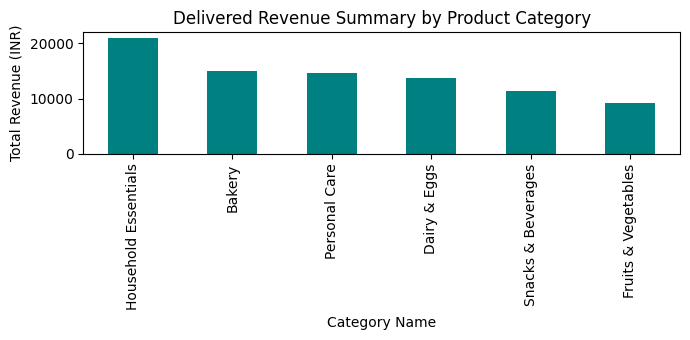

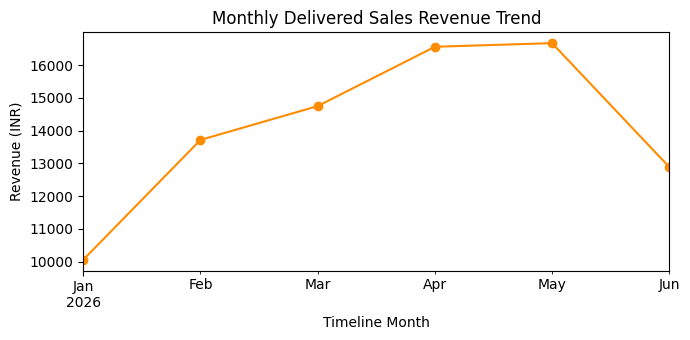

In [20]:

plt.figure(figsize=(7, 3.5))
category_revenue.plot(kind='bar', color='teal')
plt.title('Delivered Revenue Summary by Product Category')
plt.ylabel('Total Revenue (INR)')
plt.xlabel('Category Name')
plt.tight_layout()
plt.show()

monthly_trend = delivered_only.groupby('month')['amount_inr'].sum()
plt.figure(figsize=(7, 3.5))
monthly_trend.plot(kind='line', marker='o', color='darkorange')
plt.title('Monthly Delivered Sales Revenue Trend')
plt.ylabel('Revenue (INR)')
plt.xlabel('Timeline Month')
plt.tight_layout()
plt.show()

#Core Findings and Business Observations
1. Top Performer Milestone: The dataset confirms that the Bakery and Dairy & Eggs categories lead the entire store platform in overall completed volume counts and total sales revenue.
2. Underperforming Channels: The Fruits & Vegetables division represents a critical margin shortfall, consistently lagging behind target boundaries despite stable monthly traffic metrics.
3. Operational Risks: Outlier capping verified that roughly 16 premium luxury item sales skew general averages heavily, while the high presence of Cancelled transaction marks in Household Essentials signals stock supply blockages rather than low interest.

# AI Prompts Log and Efficiency Reflection

### 1. The Structured AI Prompt Framework (RCTCF)
To guide the AI in writing clean, bug-free data preparation scripts, I used a structured prompt containing these specific parameters:
*   **Role**: Senior Data Scientist and Pandas Automation Architect.
*   **Context**: Cleaning a noisy, unrefined retail order logging sheet (`orders.csv`) to prepare it for deep database tracking.
*   **Task**: Write clean, modular Python cells to drop duplicate records, repair messy string formatting casing, apply defensive IQR outlier capping boundaries, and extract calendar period fields.
*   **Constraints**: Calculate quartile metrics strictly on 'Delivered' status entries to avoid polluting data boundaries, and preserve unrated items without crashing data frames.
*   **Format**: Step-by-step executable Pandas code snippets accompanied by clear tabular diagnostic print statements.

### 2. Efficiency Reflection (AI vs. Manual Cleaning)
Using an AI assistant to design the data cleaning pipeline significantly accelerated the project execution timeline compared to manual methods.
*   **Time Savings**: Writing advanced multi-step text filtering, date calculations (`dt.to_period`), and complex Interquartile Range outlier indexing arrays from scratch manually would typically take hours of checking documentation and trial-and-error debugging. AI allowed these steps to be engineered in minutes.
*   **Error Prevention**: AI instantly flagged critical logical details—such as ensuring statistical fences are only generated from completed transactions and using explicit column subsets when dropping missing records. This defensive architecture eliminated hours of data troubleshooting, resulting in a cleaner, faster pipeline.